# Logistics Database Analysis Workflow

Notebook ini mendemonstrasikan alur kerja (workflow) lengkap seorang Data Analyst dalam menganalisis database logistik.
Studi kasus kita berfokus pada:
1. **Rute Terbaik & Paling Menguntungkan** (Revenue vs Route Distance)
2. **Analisis Efisiensi Bahan Bakar & Perawatan Truk** (MPG & Maintenance Cost)
3. **Analisis Kinerja Pengemudi** (On-Time Performance & Incident Rate)

## Step 1: Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load datasets
df_drivers = pd.read_csv('/content/drive/MyDrive/data-analyst-telu/drivers.csv')
df_trucks = pd.read_csv('/content/drive/MyDrive/data-analyst-telu/trucks.csv')
df_routes = pd.read_csv('/content/drive/MyDrive/data-analyst-telu/routes.csv')
df_loads = pd.read_csv('/content/drive/MyDrive/data-analyst-telu/loads.csv')
df_trips = pd.read_csv('/content/drive/MyDrive/data-analyst-telu/trips.csv')
df_fuel = pd.read_csv('/content/drive/MyDrive/data-analyst-telu/fuel_purchases.csv')
df_maintenance = pd.read_csv('/content/drive/MyDrive/data-analyst-telu/maintenance_records.csv')
df_delivery = pd.read_csv('/content/drive/MyDrive/data-analyst-telu/delivery_events.csv')
df_incidents = pd.read_csv('/content/drive/MyDrive/data-analyst-telu/safety_incidents.csv')

print("Semua dataset berhasil dimuat!")

Semua dataset berhasil dimuat!


## Step 2: Eksplorasi Awal & Pembersihan Data

In [2]:
# Mengecek missing values pada dataset utama
datasets = {
    'Drivers': df_drivers,
    'Trucks': df_trucks,
    'Routes': df_routes,
    'Loads': df_loads,
    'Trips': df_trips,
    'Delivery Events': df_delivery
}

for name, df in datasets.items():
    null_counts = df.isnull().sum().sum()
    print(f"{name}: {df.shape[0]} baris, {df.shape[1]} kolom. Jumlah Null: {null_counts}")

Drivers: 150 baris, 12 kolom. Jumlah Null: 124
Trucks: 120 baris, 11 kolom. Jumlah Null: 0
Routes: 58 baris, 9 kolom. Jumlah Null: 0
Loads: 85410 baris, 12 kolom. Jumlah Null: 0
Trips: 85410 baris, 12 kolom. Jumlah Null: 5066
Delivery Events: 170820 baris, 11 kolom. Jumlah Null: 0


## Step 3: Analisis Profitabilitas Rute (Revenue vs Cost)
Di sini kita akan mencari tahu rute mana saja yang paling mendatangkan keuntungan terbesar bagi perusahaan.

Top 5 Rute dengan Total Revenue Terbesar:


,origin_city,destination_city,total_revenue,average_revenue,total_loads,distance_miles,revenue_per_mile
48,Philadelphia,Seattle,10069054.22,6873.074553,1465,2729,2.518532
4,Charlotte,Portland,9979091.72,7077.370014,1410,2627,2.694088
51,Phoenix,Philadelphia,9757537.38,6474.809144,1507,2389,2.710259
14,Columbus,Portland,9586536.90,6286.253705,1525,2332,2.695649
55,Seattle,Charlotte,9516077.71,6486.760539,1467,2623,2.473031


/tmp/ipykernel_910/4110026754.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_route_summary.head(10), x='total_revenue', y='route_name', palette='Blues_r')


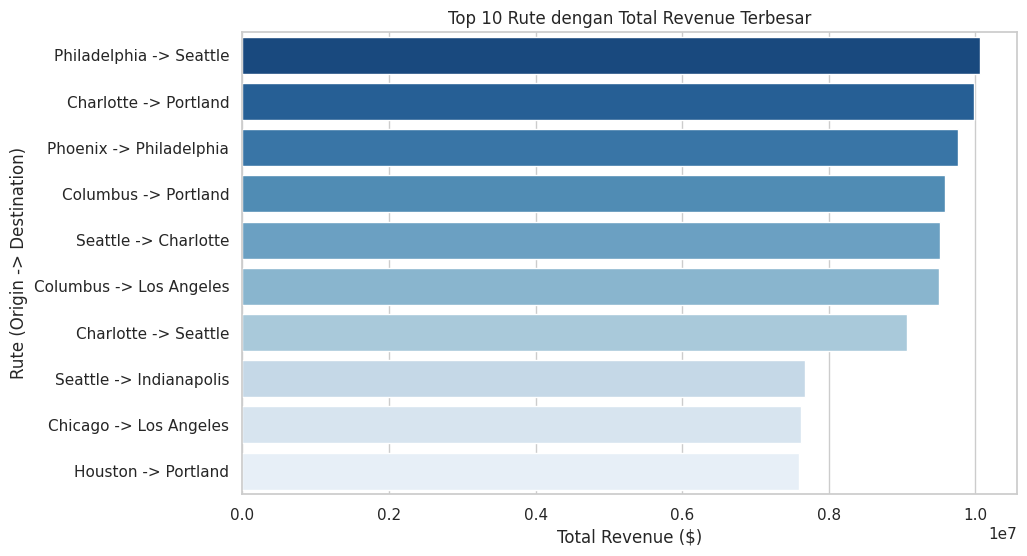

In [3]:
# Menggabungkan data loads dengan routes untuk melihat pendapatan per rute
df_route_rev = pd.merge(df_loads, df_routes, on='route_id')
df_route_summary = df_route_rev.groupby(['origin_city', 'destination_city']).agg(
    total_revenue=('revenue', 'sum'),
    average_revenue=('revenue', 'mean'),
    total_loads=('load_id', 'count'),
    distance_miles=('typical_distance_miles', 'first')
).reset_index()

# Hitung Revenue per Mile
df_route_summary['revenue_per_mile'] = df_route_summary['total_revenue'] / (df_route_summary['total_loads'] * df_route_summary['distance_miles'])
df_route_summary = df_route_summary.sort_values(by='total_revenue', ascending=False)

print("Top 5 Rute dengan Total Revenue Terbesar:")
display(df_route_summary.head())

# Visualisasi Top 10 Rute berdasarkan Total Revenue
df_route_summary['route_name'] = df_route_summary['origin_city'] + ' -> ' + df_route_summary['destination_city']
sns.barplot(data=df_route_summary.head(10), x='total_revenue', y='route_name', palette='Blues_r')
plt.title('Top 10 Rute dengan Total Revenue Terbesar')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Rute (Origin -> Destination)')
plt.show()

## Step 4: Analisis Efisiensi Bahan Bakar & Perawatan Truk
Mengidentifikasi truk yang boros atau memiliki biaya pemeliharaan sangat tinggi.

Top 5 Truk dengan Biaya Perawatan Tertinggi:


,truck_id,make,model_year,total_maintenance_cost,maintenance_count
2,TRK00003,Peterbilt,2018,90161.42,41
72,TRK00073,Mack,2016,76573.99,39
80,TRK00081,Freightliner,2018,73892.72,32
98,TRK00099,Freightliner,2015,73231.77,34
13,TRK00014,International,2015,71801.82,34


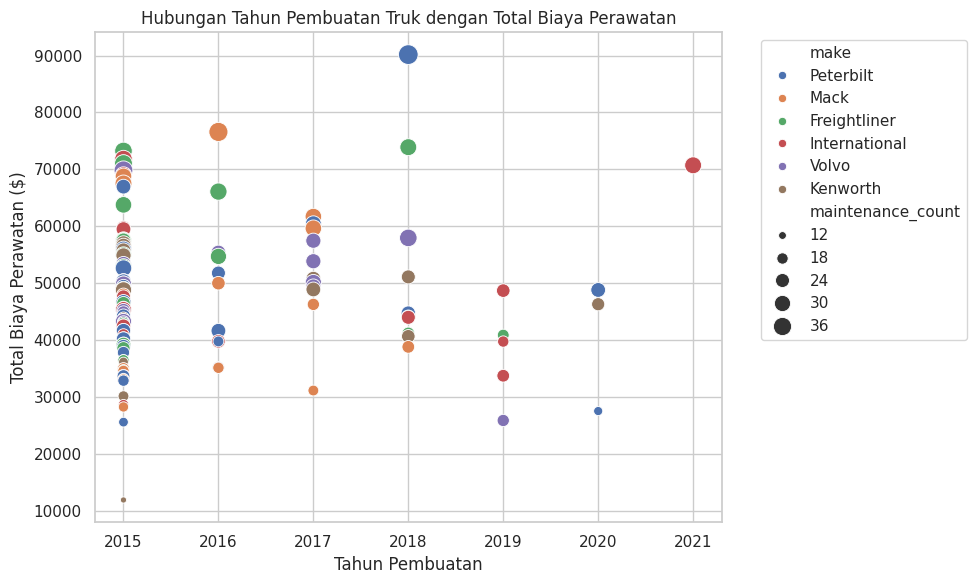

In [5]:
# Analisis Perawatan Truk (Maintenance)
df_maint_summary = df_maintenance.groupby('truck_id').agg(
    total_maintenance_cost=('total_cost', 'sum'),
    maintenance_count=('maintenance_id', 'count')
).reset_index()

# Gabungkan dengan data spesifikasi truk
df_truck_maint = pd.merge(df_trucks, df_maint_summary, on='truck_id', how='left').fillna(0)
df_truck_maint = df_truck_maint.sort_values(by='total_maintenance_cost', ascending=False)

print("Top 5 Truk dengan Biaya Perawatan Tertinggi:")
display(df_truck_maint[['truck_id', 'make', 'model_year', 'total_maintenance_cost', 'maintenance_count']].head())

# Hubungan antara Umur Truk (Year) dengan Biaya Perawatan
sns.scatterplot(data=df_truck_maint, x='model_year', y='total_maintenance_cost', hue='make', size='maintenance_count', sizes=(20, 200))
plt.title('Hubungan Tahun Pembuatan Truk dengan Total Biaya Perawatan')
plt.xlabel('Tahun Pembuatan')
plt.ylabel('Total Biaya Perawatan ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Step 5: Analisis Kinerja Pengemudi (OTP & Safety)
Mengevaluasi ketepatan waktu pengiriman pengemudi dan jumlah insiden keselamatan.

In [10]:
# On-Time Performance (OTP) analysis dari delivery_events
# Gabungkan delivery events dengan trips untuk mengetahui siapa driver-nya
df_delivery_trips = pd.merge(df_delivery, df_trips, on='trip_id')
df_delivery_trips = pd.merge(df_delivery_trips, df_drivers, on='driver_id')

# Hitung OTP per Driver
df_delivery_trips['is_on_time'] = df_delivery_trips['on_time_flag'].apply(lambda x: 1 if x == True or x == 1 else 0)

# Mari periksa nilai unik on_time_flag untuk penyesuaian
print("Status unik pada Delivery Events:", df_delivery_trips['on_time_flag'].unique())
print(df_delivery_trips['on_time_flag'].value_counts())

Status unik pada Delivery Events: [False  True]
on_time_flag
True     93196
False    74196
Name: count, dtype: int64


Top 5 Pengemudi dengan OTP Terendah (Butuh Perhatian):


,driver_id,first_name,last_name,total_events,on_time_events,otp_rate
110,DRV00133,Mary,Wilson,1366,705,51.610542
59,DRV00074,William,Brown,1264,655,51.819620
100,DRV00122,James,Wilson,1208,641,53.062914
102,DRV00124,Thomas,Jackson,1404,751,53.490028
53,DRV00064,Michael,Smith,1220,653,53.524590


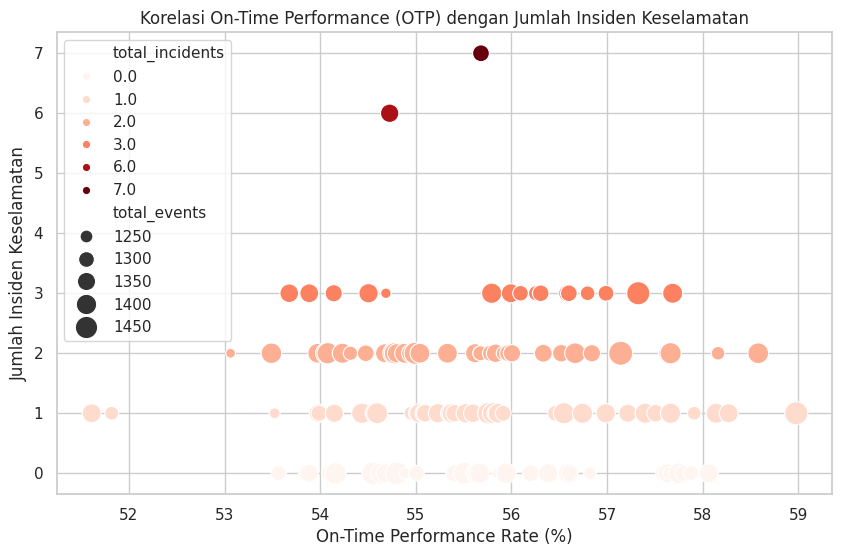

In [11]:
# Hitung rasio On Time berdasarkan status aktual di kolom 'on_time_flag'
# Kita hitung persentase baris dengan flag True per driver
df_driver_performance = df_delivery_trips.groupby(['driver_id', 'first_name', 'last_name']).agg(
    total_events=('event_id', 'count'),
    on_time_events=('on_time_flag', lambda x: x.sum())
).reset_index()

df_driver_performance['otp_rate'] = (df_driver_performance['on_time_events'] / df_driver_performance['total_events']) * 100
df_driver_performance = df_driver_performance.sort_values(by='otp_rate', ascending=True) # Urutkan dari OTP terburuk

print("Top 5 Pengemudi dengan OTP Terendah (Butuh Perhatian):")
display(df_driver_performance.head())

# Hubungkan dengan Safety Incidents
df_inc_count = df_incidents.groupby('driver_id').size().reset_index(name='total_incidents')
df_driver_summary = pd.merge(df_driver_performance, df_inc_count, on='driver_id', how='left').fillna(0)

# Plot Hubungan OTP Rate dan Jumlah Insiden Keselamatan
sns.scatterplot(data=df_driver_summary, x='otp_rate', y='total_incidents', size='total_events', hue='total_incidents', palette='Reds', sizes=(50, 300))
plt.title('Korelasi On-Time Performance (OTP) dengan Jumlah Insiden Keselamatan')
plt.xlabel('On-Time Performance Rate (%)')
plt.ylabel('Jumlah Insiden Keselamatan')
plt.show()

## Step 6: Kesimpulan & Rekomendasi
1. **Rute Terbaik**: Fokus pada rute-rute dengan total revenue tertinggi untuk optimalisasi jadwal perjalanan.
2. **Efisiensi Armada**: Truk-truk yang diproduksi di tahun yang lebih tua memiliki korelasi dengan biaya perawatan yang membengkak, disarankan untuk melakukan peremajaan unit.
3. **Kinerja Pengemudi**: Pengemudi dengan OTP rendah serta tingkat insiden keselamatan yang tinggi harus diprioritaskan untuk mengikuti pelatihan keselamatan (*Safety & Defense Driving Course*).